In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rakuzai/pasd-gambling/train.csv
/kaggle/input/datasets/rakuzai/pasd-gambling/test.csv
/kaggle/input/datasets/rakuzai/pasd-gambling/holdout.csv


In [22]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:0000:01


In [35]:
import re
import nltk
import time
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

In [36]:
train = pd.read_csv('/kaggle/input/datasets/rakuzai/pasd-gambling/train.csv')
test = pd.read_csv('/kaggle/input/datasets/rakuzai/pasd-gambling/test.csv')
holdout = pd.read_csv('/kaggle/input/datasets/rakuzai/pasd-gambling/holdout.csv', sep=';')

In [37]:
print(train.head())
print(test.head())
print(holdout.head())

print(train.tail())
print(test.tail())
print(holdout.tail())

                                             comment  label
0                                     aamiin ya rabb      0
1  terima kasih mengajak jalan2 virtual raja ampa...      0
2                                        bener prabu      0
3                               tonton video ya hehe      0
4  coach nova plis suruh pda bljr sepak penalti a...      0
                                             comment  label
0                    255 bangun pagi indonesia cerah      0
1              maksudnya bangg medyyfacepurplecrying      0
2     suka banget klo prodcash narsum nya dr tirta ❤      0
3  bkn gamernya kya nya tp fansnya kyanya sih bin...      0
4       manamana ngomongin 𝐌𝐀𝐍𝘿𝘼𝙇𝙄𝙆𝘼𝟕𝟕 keren sih ✌ ✌      1
                                             comment  label
0                   modal kaya coba aja 𝑲𝑰𝑵𝑮𝟑𝟐𝟖 🔥 💰💎      1
1                   herantapidunia serius bg idup lu      0
2  coba unboxing sukuna ajah gojo mah dikalahkan ...      0
3  seru banget eps iklan tetep w panteng

In [38]:
print(train.info())
print(test.info())
print(holdout.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8171 entries, 0 to 8170
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  8171 non-null   object
 1   label    8171 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 127.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2335 entries, 0 to 2334
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  2335 non-null   object
 1   label    2335 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 36.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  1167 non-null   object
 1   label    1167 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 18.4+ KB
None


In [39]:
nltk.download('stopwords')

# Initialize stemmer and stopword list
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))  # stopwords bahasa Indonesia

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
import re

# Preprocessing function
def preprocess_text(text):
    text = text.lower()  # lowercase
    # Define emoji pattern (Unicode ranges)
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F700-\U0001F77F"  # Alchemical symbols
        u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
        u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
        u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
        u"\U0001FA00-\U0001FA6F"  # Chess Symbols
        u"\U0001FA70-\U0001FAFF"  # Extended-B
        u"\u2600-\u26FF"          # Misc symbols
        u"\u2700-\u27BF"          # Dingbats
    "]+", flags=re.UNICODE)
    
    # Extract emojis to preserve them
    emojis = emoji_pattern.findall(text)
    # Remove punctuation and special characters, keep letters, digits, spaces
    text = re.sub(r'[^\w\s\d]', '', text)
    # Reinsert emojis at end or modify this to reinsert at original positions
    text = text.strip() + ' ' + ' '.join(emojis)
    # Tokenize
    tokens = text.split()
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return ' '.join(tokens)

In [42]:
train['comment'] = train['comment'].astype(str).apply(preprocess_text)
test['comment'] = test['comment'].astype(str).apply(preprocess_text)
holdout['comment'] = holdout['comment'].astype(str).apply(preprocess_text)

In [43]:
print(train.head())
print(test.head())
print(holdout.head())

                                             comment  label
0                                     aamiin ya rabb      0
1  terima kasih mengajak jalan2 virtual raja ampa...      0
2                                        bener prabu      0
3                               tonton video ya hehe      0
4  coach nova plis suruh pda bljr sepak penalti a...      0
                                             comment  label
0                    255 bangun pagi indonesia cerah      0
1              maksudnya bangg medyyfacepurplecrying      0
2     suka banget klo prodcash narsum nya dr tirta ❤      0
3  bkn gamernya kya nya tp fansnya kyanya sih bin...      0
4       manamana ngomongin 𝐌𝐀𝐍𝘿𝘼𝙇𝙄𝙆𝘼𝟕𝟕 keren sih ✌ ✌      1
                                             comment  label
0                   modal kaya coba aja 𝑲𝑰𝑵𝑮𝟑𝟐𝟖 🔥 💰💎      1
1                   herantapidunia serius bg idup lu      0
2  coba unboxing sukuna ajah gojo mah dikalahkan ...      0
3  seru banget eps iklan tetep w panteng

In [44]:
X = train['comment']
y = train['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [45]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [46]:
# Models to evaluate
models = {
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": cb.CatBoostClassifier(random_state=42, verbose=False),
}


=== XGBoost ===
Accuracy: 0.95963
Confusion Matrix:
 [[1487    5]
 [  61   82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1492
           1       0.94      0.57      0.71       143

    accuracy                           0.96      1635
   macro avg       0.95      0.79      0.85      1635
weighted avg       0.96      0.96      0.96      1635


=== LightGBM ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.95107
Confusion Matrix:
 [[1481   11]
 [  69   74]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1492
           1       0.87      0.52      0.65       143

    accuracy                           0.95      1635
   macro avg       0.91      0.76      0.81      1635
weighted avg       0.95      0.95      0.95      1635


=== CatBoost ===
Accuracy: 0.96758
Confusion Matrix:
 [[1488    4]
 [  49   94]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1492
           1       0.96      0.66      0.78       143

    accuracy                           0.97      1635
   macro avg       0.96      0.83      0.88      1635
weighted avg       0.97      0.97      0.96      1635


FINAL RESULTS SUMMARY (sorted by accuracy)
CatBoost                 : 0.96758
XGBoost                  : 0.95963
LightGBM                 : 0.95107


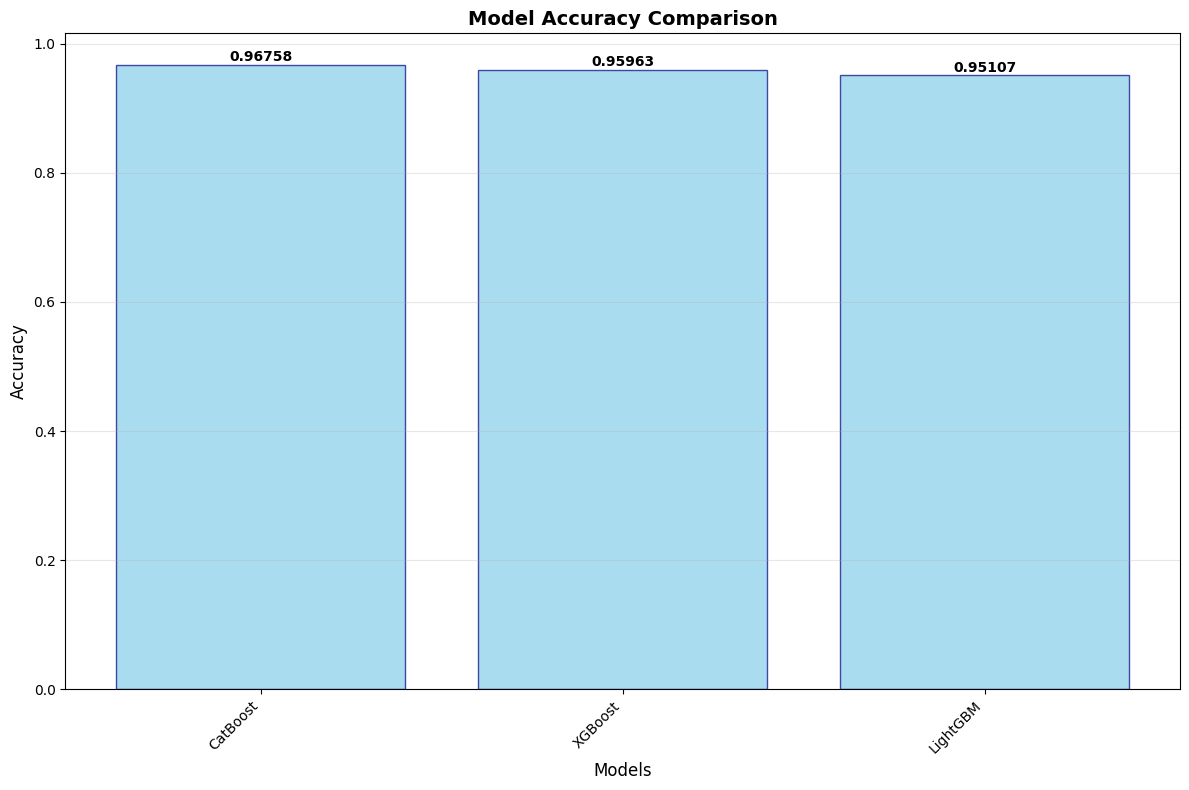

In [47]:
# Store results for plotting
results = {}

# Evaluate each model
for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Handle sparse matrix requirements for different models
    if name in ["Hist Gradient Boosting", "XGBoost", "LightGBM", "CatBoost"]:
        # These models require dense arrays
        X_train_dense = X_train_vec.toarray() if hasattr(X_train_vec, 'toarray') else X_train_vec
        X_test_dense = X_test_vec.toarray() if hasattr(X_test_vec, 'toarray') else X_test_vec
        model.fit(X_train_dense, y_train)
        y_pred = model.predict(X_test_dense)
    else:
        # These models can handle sparse matrices
        model.fit(X_train_vec, y_train)
        y_pred = model.predict(X_test_vec)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"Accuracy: {accuracy:.5f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Create a DataFrame for better visualization
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)

# Plot the results
plt.figure(figsize=(12, 8))
bars = plt.bar(range(len(results_df)), results_df['Accuracy'], color='skyblue', edgecolor='navy', alpha=0.7)

# Add value labels on bars with 5 decimal places
for i, (idx, row) in enumerate(results_df.iterrows()):
    plt.text(i, row['Accuracy'] + 0.001, f'{row["Accuracy"]:.5f}', 
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xticks(range(len(results_df)), results_df['Model'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Print sorted results with 5 decimal places
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY (sorted by accuracy)")
print("="*50)
for idx, row in results_df.iterrows():
    print(f"{row['Model']:<25}: {row['Accuracy']:.5f}")

plt.show()

In [51]:
# Transform test & holdout pakai TF-IDF yang sudah di-fit dari train
X_test_full = vectorizer.transform(test['comment'])
X_holdout = vectorizer.transform(holdout['comment'])

y_test_full = test['label']
y_holdout = holdout['label']

print("\n" + "="*50)
print("EVALUATION ON TEST & HOLDOUT")
print("="*50)

for name, model in models.items():
    print(f"\n=== {name} (Test & Holdout) ===")
    
    # Dense kalau perlu
    if name in ["XGBoost", "LightGBM", "CatBoost"]:
        X_test_full_dense = X_test_full.toarray()
        X_holdout_dense = X_holdout.toarray()
        
        y_pred_test = model.predict(X_test_full_dense)
        y_pred_holdout = model.predict(X_holdout_dense)
    else:
        y_pred_test = model.predict(X_test_full)
        y_pred_holdout = model.predict(X_holdout)
    
    # TEST
    acc_test = accuracy_score(y_test_full, y_pred_test)
    print(f"\n[Test] Accuracy: {acc_test:.5f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test_full, y_pred_test))
    print("Classification Report:\n", classification_report(y_test_full, y_pred_test))
    
    # HOLDOUT
    acc_holdout = accuracy_score(y_holdout, y_pred_holdout)
    print(f"\n[Holdout] Accuracy: {acc_holdout:.5f}")
    print("Confusion Matrix:\n", confusion_matrix(y_holdout, y_pred_holdout))
    print("Classification Report:\n", classification_report(y_holdout, y_pred_holdout))


EVALUATION ON TEST & HOLDOUT

=== XGBoost (Test & Holdout) ===

[Test] Accuracy: 0.91949
Confusion Matrix:
 [[2118    8]
 [ 180   29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      2126
           1       0.78      0.14      0.24       209

    accuracy                           0.92      2335
   macro avg       0.85      0.57      0.60      2335
weighted avg       0.91      0.92      0.89      2335


[Holdout] Accuracy: 0.80634
Confusion Matrix:
 [[939   3]
 [223   2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.89       942
           1       0.40      0.01      0.02       225

    accuracy                           0.81      1167
   macro avg       0.60      0.50      0.45      1167
weighted avg       0.73      0.81      0.72      1167


=== LightGBM (Test & Holdout) ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[Test] Accuracy: 0.90792
Confusion Matrix:
 [[2103   23]
 [ 192   17]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95      2126
           1       0.42      0.08      0.14       209

    accuracy                           0.91      2335
   macro avg       0.67      0.54      0.54      2335
weighted avg       0.87      0.91      0.88      2335


[Holdout] Accuracy: 0.80034
Confusion Matrix:
 [[931  11]
 [222   3]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.99      0.89       942
           1       0.21      0.01      0.03       225

    accuracy                           0.80      1167
   macro avg       0.51      0.50      0.46      1167
weighted avg       0.69      0.80      0.72      1167


=== CatBoost (Test & Holdout) ===

[Test] Accuracy: 0.91820
Confusion Matrix:
 [[2110   16]
 [ 175   34]]
Classification Report:
               precision 

In [52]:
import os
import joblib

# folder simpan
os.makedirs("saved_models", exist_ok=True)

for name, model in models.items():
    filename = f"saved_models/{name.lower().replace(' ', '_')}.pkl"
    joblib.dump(model, filename)
    print(f"{name} saved to {filename}")

# save TF-IDF vectorizer juga (penting!)
joblib.dump(vectorizer, "saved_models/tfidf_vectorizer.pkl")

print("\nSemua model & vectorizer berhasil disimpan.")

XGBoost saved to saved_models/xgboost.pkl
LightGBM saved to saved_models/lightgbm.pkl
CatBoost saved to saved_models/catboost.pkl

Semua model & vectorizer berhasil disimpan.
